# Substituční šifra: demonstrační notebook

Notebook krok za krokem ukazuje práci se substituční šifrou, přípravu referenčního textu, tvorbu bigramové matice a krátkou demonstrační kryptoanalýzu. Jediným referenčním textem je **Válka s mloky**.

Cílem notebooku je vysvětlit postup, ne spouštět dlouhé dávkové dešifrování všech souborů ze zadání.

## 1. Používaná abeceda

Projekt používá pevnou abecedu `ABCDEFGHIJKLMNOPQRSTUVWXYZ_`. Obsahuje 26 písmen a jeden znak `_`, který představuje mezeru. Jiná abeceda se v řešení nenabízí, aby bylo chování přesně podle zadání.

In [1]:
from pathlib import Path
import inspect
import random
import sys
import tempfile

import numpy as np

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None
    print("matplotlib není nainstalovaný, vizualizace se přeskočí.")

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from substitution_cipher import (
    ALPHABET,
    SubstitutionCipher,
    get_bigrams,
    plausibility,
    prolom_substitute,
    substitute_decrypt,
    substitute_encrypt,
    transition_matrix,
)
from substitution_cipher.bigrams import absolute_bigram_matrix
from substitution_cipher.cipher import validate_key
from substitution_cipher.io_utils import load_matrix
from substitution_cipher.paths import (
    CIPHERTEXT_DIR,
    CLEAN_REFERENCE_TEXT_PATH,
    OUTPUT_DIR,
    RAW_REFERENCE_TEXT_PATH,
    REFERENCE_MATRIX_PATH,
    TEACHER_EXAMPLE_DIR,
)
from substitution_cipher.preprocessing import clean_text, validate_clean_text

print(ALPHABET)
print("Počet znaků:", len(ALPHABET))

ABCDEFGHIJKLMNOPQRSTUVWXYZ_
Počet znaků: 27


## 2. Struktura projektu

Knihovní logika je ve `src/substitution_cipher/`. Spouštěcí skripty jsou ve `scripts/`. Referenční text je v `data/reference/`, ciphertexty v `data/ciphertexts/`, matice v `models/` a výsledky v `outputs/`.

In [2]:
for path in [
    "src/substitution_cipher",
    "scripts",
    "data/reference",
    "data/ciphertexts",
    "models",
    "outputs",
    "reports",
]:
    print(path, "existuje:", (PROJECT_ROOT / path).exists())

src/substitution_cipher existuje: False
scripts existuje: False
data/reference existuje: False
data/ciphertexts existuje: False
models existuje: False
outputs existuje: False
reports existuje: False


## 3. Surový text Války s mloky

Surový text se čte jako UTF-8. V notebooku zobrazujeme jen krátkou ukázku, protože celý soubor je dlouhý a pro vysvětlení není potřeba.

In [3]:
raw_text = RAW_REFERENCE_TEXT_PATH.read_text(encoding="utf-8")
print("Cesta:", RAW_REFERENCE_TEXT_PATH)
print("Délka surového textu:", len(raw_text))
print(raw_text[:300].replace("\n", " "))

Cesta: D:\unicorn\python\data\reference\valka_s_mloky_raw.txt
Délka surového textu: 401043
Kdybyste hledali ostrůvek Tana Masa na mapě, našli byste jej právě na rovníku kousek na západ od Sumatry; ale kdybyste se zeptali na palubě lodi Kandong Bandoeng kapitána J. van Tocha, co to je tahle Tana Masa, před kterou právě zakotvil, nadával by chvíli a pak by vám řekl, že to je ta nejšpinavějš


## 4. Čištění textu

Čištění odstraní diakritiku, převede text na velká písmena, oddělovače převede na `_`, odstraní číslice a interpunkci a ponechá pouze `A-Z_`. Výsledek se ukládá do `data/reference/valka_s_mloky_clean.txt`.

In [4]:
clean_preview = clean_text(raw_text[:1000])
clean_reference = CLEAN_REFERENCE_TEXT_PATH.read_text(encoding="utf-8").strip()
validate_clean_text(clean_reference)

print("Ukázka po vyčištění:", clean_preview[:160])
print("Délka vyčištěného textu:", len(clean_reference))
print("Nepovolené znaky:", sorted(set(clean_reference) - set(ALPHABET)))

Ukázka po vyčištění: KDYBYSTE_HLEDALI_OSTRUVEK_TANA_MASA_NA_MAPE_NASLI_BYSTE_JEJ_PRAVE_NA_ROVNIKU_KOUSEK_NA_ZAPAD_OD_SUMATRY_ALE_KDYBYSTE_SE_ZEPTALI_NA_PALUBE_LODI_KANDONG_BANDOENG_
Délka vyčištěného textu: 381933
Nepovolené znaky: []


## 5. Bigramy

Bigram je dvojice sousedních znaků. Například z textu `KRYPTOSYSTEM` vzniknou dvojice `KR`, `RY`, `YP`, `PT`, `TO`, `OS`, `SY`, `YS`, `ST`, `TE`, `EM`.

In [5]:
example = "KRYPTOSYSTEM"
print(get_bigrams(example))

reference_bigrams = get_bigrams(clean_reference)
print("Počet bigramů v referenčním textu:", len(reference_bigrams))

['KR', 'RY', 'YP', 'PT', 'TO', 'OS', 'SY', 'YS', 'ST', 'TE', 'EM']
Počet bigramů v referenčním textu: 381932


## 6. Absolutní bigramová matice

Matice má rozměr `27 × 27`. Řádky představují první znak bigramu, sloupce druhý znak a hodnota říká, kolikrát se daná dvojice v textu objevila.

In [6]:
absolute_raw = absolute_bigram_matrix(reference_bigrams)
print("Shape:", absolute_raw.shape)
print("Součet absolutních četností:", int(absolute_raw.sum()))
print("Četnost bigramu VA:", int(absolute_raw[ALPHABET.index("V"), ALPHABET.index("A")]))

Shape: (27, 27)
Součet absolutních četností: 381932
Četnost bigramu VA: 2350


## 7. Ošetření nul

Některé bigramy se v referenčním textu nemusí vyskytnout. Jejich buňky mají hodnotu nula. Před normalizací se proto nuly nahradí jedničkou, aby při výpočtu věrohodnosti nevznikl `log(0)`.

In [7]:
zero_count_before = int(np.sum(absolute_raw == 0.0))
absolute_smoothed = transition_matrix(reference_bigrams)
zero_count_after = int(np.sum(absolute_smoothed == 0.0))

print("Počet nul před ošetřením:", zero_count_before)
print("Počet nul po ošetření:", zero_count_after)

Počet nul před ošetřením: 139
Počet nul po ošetření: 0


## 8. Relativní referenční matice

Relativní matice vznikne normalizací absolutní matice: `relative_matrix = absolute_matrix / absolute_matrix.sum()`. Ukládá se do `models/TM_ref.npy`.

In [8]:
relative_matrix = absolute_smoothed / absolute_smoothed.sum()
matrix = load_matrix(REFERENCE_MATRIX_PATH) if REFERENCE_MATRIX_PATH.exists() else relative_matrix

print("Cesta k matici:", REFERENCE_MATRIX_PATH)
print("Shape:", matrix.shape)
print("Součet:", matrix.sum())
print("Počet nul:", int(np.sum(matrix == 0.0)))
print("Obsahuje NaN:", bool(np.isnan(matrix).any()))
print("Obsahuje nekonečné hodnoty:", bool(np.isinf(matrix).any()))

Cesta k matici: D:\unicorn\python\models\TM_ref.npy
Shape: (27, 27)
Součet: 1.0
Počet nul: 0
Obsahuje NaN: False
Obsahuje nekonečné hodnoty: False


## 9. Vizualizace matice

Heatmapa zobrazuje logaritmy pravděpodobností bigramů. Světlejší oblasti odpovídají častějším dvojicím znaků v referenčním textu.

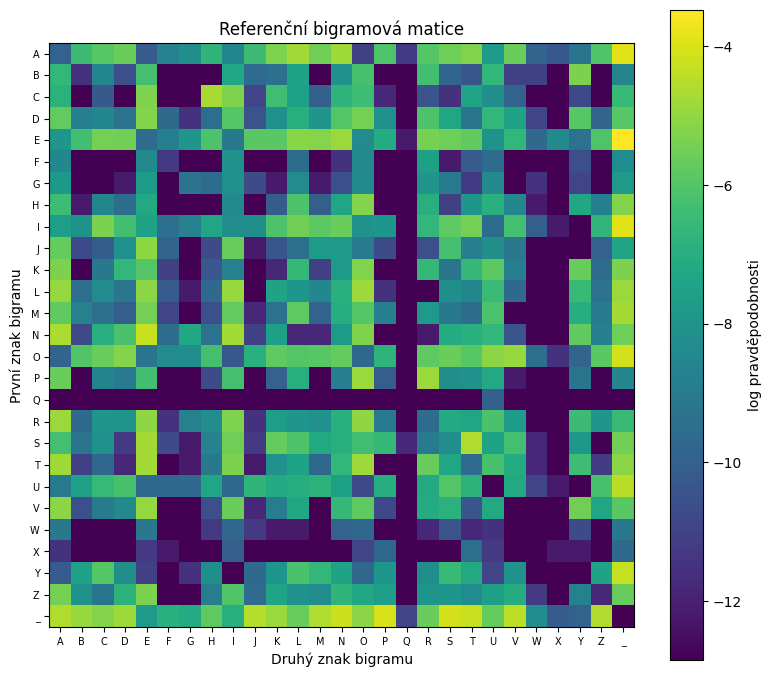

In [9]:
if plt is None:
    print("Vizualizace se přeskočila, protože matplotlib není nainstalovaný.")
else:
    fig, ax = plt.subplots(figsize=(8, 7))
    image = ax.imshow(np.log(matrix), cmap="viridis")
    ax.set_title("Referenční bigramová matice")
    ax.set_xlabel("Druhý znak bigramu")
    ax.set_ylabel("První znak bigramu")
    ax.set_xticks(range(len(ALPHABET)))
    ax.set_xticklabels(list(ALPHABET), fontsize=7)
    ax.set_yticks(range(len(ALPHABET)))
    ax.set_yticklabels(list(ALPHABET), fontsize=7)
    fig.colorbar(image, ax=ax, label="log pravděpodobnosti")
    plt.tight_layout()
    plt.show()

## 10. Substituční klíč

Klíč je permutace celé abecedy. Má délku 27 a každý znak se v něm objeví právě jednou.

In [10]:
demo_key = ALPHABET[3:] + ALPHABET[:3]
validate_key(demo_key)
print("Klíč:", demo_key)
print("Délka:", len(demo_key))

Klíč: DEFGHIJKLMNOPQRSTUVWXYZ_ABC
Délka: 27


## 11. Šifrování

Při šifrování se každý znak plaintextu nahradí znakem na stejné pozici v klíči. Ukázka používá povinnou funkci i objektové API.

In [11]:
plaintext = "AHOJ_SVETE"
ciphertext = substitute_encrypt(plaintext, demo_key)
cipher = SubstitutionCipher(matrix)

print("Plaintext:", plaintext)
print("Ciphertext:", ciphertext)
print("Objektové API:", cipher.encrypt(plaintext, demo_key))

Plaintext: AHOJ_SVETE
Ciphertext: DKRMCVYHWH
Objektové API: DKRMCVYHWH


## 12. Dešifrování

Dešifrování používá inverzní mapování. Kontrola `decrypted == plaintext` ověřuje, že se text vrátil do původního tvaru.

In [12]:
decrypted = substitute_decrypt(ciphertext, demo_key)
print("Dešifrováno:", decrypted)
print("Sedí:", decrypted == plaintext)
print("Objektové API:", cipher.decrypt(ciphertext, demo_key))

Dešifrováno: AHOJ_SVETE
Sedí: True
Objektové API: AHOJ_SVETE


## 13. Věrohodnost textu

Funkce `plausibility` hodnotí text podle bigramové matice. Vyšší, tedy méně záporné skóre, obvykle znamená jazykově pravděpodobnější text.

In [13]:
normal_text = clean_text("Toto je krátký český text pro ukázku")
rng = random.Random(7)
shuffled_text = "".join(rng.sample(list(normal_text), len(normal_text)))

print("Normální text:", normal_text)
print("Přeházený text:", shuffled_text)
print("Skóre normálního textu:", plausibility(normal_text, matrix))
print("Skóre přeházeného textu:", plausibility(shuffled_text, matrix))

Normální text: TOTO_JE_KRATKY_CESKY_TEXT_PRO_UKAZKU
Přeházený text: _R_O_PSATKOEEZTYUT_UYTCKEOK_XKR_JATK
Skóre normálního textu: -191.47567672683735
Skóre přeházeného textu: -247.5802980799379


## 14. Metropolis-Hastingsův algoritmus

Povinný algoritmus ze zadání:

1. vytvoří náhodný počáteční klíč,
2. dešifruje ciphertext,
3. spočítá skóre,
4. prohodí dva náhodné znaky v klíči,
5. znovu dešifruje a spočítá skóre,
6. lepší kandidát přijme vždy,
7. horší kandidát přijme s pravděpodobností `0.01`,
8. uchovává nejlepší výsledek,
9. opakuje postup po zadaný počet iterací.

Volitelné rozšíření `polish_key` a restarty jsou vlastní doplnění, ne náhrada povinného algoritmu.

## 15. Povinné funkční API

Následující buňka vypíše skutečné podpisy veřejných funkcí požadovaných zadáním.

In [14]:
for function in [
    substitute_encrypt,
    substitute_decrypt,
    get_bigrams,
    transition_matrix,
    plausibility,
    prolom_substitute,
]:
    print(function.__name__, inspect.signature(function))

substitute_encrypt (plaintext: 'str', key: 'str') -> 'str'
substitute_decrypt (ciphertext: 'str', key: 'str') -> 'str'
get_bigrams (text: 'str') -> 'list[str]'
transition_matrix (bigrams: 'list[str]') -> 'np.ndarray'
plausibility (text: 'str', TM_ref: 'np.ndarray') -> 'float'
prolom_substitute (text: 'str', TM_ref: 'np.ndarray', iter: 'int', start_key: 'str | None' = None) -> 'tuple[str, str, float]'


## 16. Objektové API

`SubstitutionCipher` je pohodlná fasáda. `CrackResult` obsahuje `plaintext`, `key`, `score`, `restart` a `iterations`.

In [15]:
cipher = SubstitutionCipher.from_matrix_file(REFERENCE_MATRIX_PATH)
print(type(cipher).__name__)
print("Matice načtena:", cipher.reference_matrix.shape)

SubstitutionCipher
Matice načtena: (27, 27)


## 17. Krátká demonstrační kryptoanalýza

Tato ukázka používá malý počet iterací, aby notebook běžel rychle. Nejde o finální dávkové dešifrování.

In [16]:
demo_plaintext = "AHOJ_SVETE_TOTO_JE_KRATKA_UKAZKA"
demo_ciphertext = substitute_encrypt(demo_plaintext, demo_key)
demo_result = cipher.crack(
    demo_ciphertext,
    iterations=20,
    restarts=1,
    seed=1,
    polish=False,
    progress_every=0,
)

print("Ciphertext:", demo_ciphertext)
print("Nalezený plaintext:", demo_result.plaintext)
print("Nalezený klíč:", demo_result.key)
print("Skóre:", demo_result.score)
print("Iterace:", demo_result.iterations)

Restart 1/1 nejlepší plausibility: -231.06698828847985
Celkově nejlepší restart: 1, plausibility: -231.06698828847985
Ciphertext: DKRMCVYHWHCWRWRCMHCNUDWNDCXNDBND
Nalezený plaintext: MFLBKRHOEOKELELKBOKJSMEJMKAJMUJM
Nalezený klíč: XMLPWKFYTNCRDAHZGVUOBQIJ_SE
Skóre: -231.06698828847985
Iterace: 20


## 18. Zpracování jednoho souboru

Metoda `crack_file` načte soubor ve tvaru `text_1000_sample_1_ciphertext.txt` a uloží dvojici `plaintext` a `key`. Ukázka používá dočasnou složku a jeden velmi krátký soubor.

In [17]:
with tempfile.TemporaryDirectory() as tmp:
    tmp_path = Path(tmp)
    input_path = tmp_path / "text_3_sample_1_ciphertext.txt"
    output_path = tmp_path / "out"
    input_path.write_text("ABC", encoding="utf-8")
    result = cipher.crack_file(input_path, output_path, iterations=1, polish=False)
    print(sorted(path.name for path in output_path.glob("*.txt")))
    print(result.iterations)

Restart 1/1 nejlepší plausibility: -12.376037834426118
Celkově nejlepší restart: 1, plausibility: -12.376037834426118
['text_3_sample_1_key.txt', 'text_3_sample_1_plaintext.txt']
1


## 19. Zpracování celé složky

Metoda `crack_directory` zpracuje všechny ciphertexty ve složce `data/ciphertexts/` a uloží výstupy do `outputs/`. V notebooku se plný běh nespouští, protože může trvat dlouho.

In [18]:
ciphertext_files = sorted(CIPHERTEXT_DIR.glob("text_*_sample_*_ciphertext.txt"))
print("Počet dostupných ciphertextů:", len(ciphertext_files))
print("Finální běh spusťte příkazem:")
print(r"python scripts\decrypt_samples.py --matrix models\TM_ref.npy --input-directory data\ciphertexts --output-directory outputs --iterations 20000 --restarts 1 --workers 0")

Počet dostupných ciphertextů: 60
Finální běh spusťte příkazem:
python scripts\decrypt_samples.py --matrix models\TM_ref.npy --input-directory data\ciphertexts --output-directory outputs --iterations 20000 --restarts 1 --workers 0


## 20. Kontrola učitelského příkladu

Teacher plaintext a key se používají pouze pro následnou kontrolu, nikdy během hledání. Pokud nový výstup ještě neexistuje, notebook vypíše jasnou zprávu.

In [19]:
teacher_plaintext_path = TEACHER_EXAMPLE_DIR / "text_1000_sample_1_plaintext.txt"
teacher_key_path = TEACHER_EXAMPLE_DIR / "text_1000_sample_1_key.txt"
output_plaintext_path = OUTPUT_DIR / "text_1000_sample_1_plaintext.txt"
output_key_path = OUTPUT_DIR / "text_1000_sample_1_key.txt"

if teacher_plaintext_path.exists() and output_plaintext_path.exists():
    teacher_plaintext = teacher_plaintext_path.read_text(encoding="utf-8").strip()
    output_plaintext = output_plaintext_path.read_text(encoding="utf-8").strip()
    matching = sum(a == b for a, b in zip(teacher_plaintext, output_plaintext, strict=False))
    print("Shodné znaky:", matching, "/", len(teacher_plaintext))
    print("Procento shody:", matching / len(teacher_plaintext) * 100)
    print("Plaintext přesně:", teacher_plaintext == output_plaintext)
    if teacher_key_path.exists() and output_key_path.exists():
        print("Key přesně:", teacher_key_path.read_text(encoding="utf-8").strip() == output_key_path.read_text(encoding="utf-8").strip())
else:
    print("Nový finální výstup zatím není vytvořen. Nejdříve spusťte dávkové dešifrování.")

Shodné znaky: 1000 / 1000
Procento shody: 100.0
Plaintext přesně: True
Key přesně: False


## 21. Omezení

Metropolis-Hastingsův algoritmus je náhodný a různé seedy mohou vést k různým výsledkům. Kratší texty jsou obtížnější, protože obsahují méně bigramů. Bigramový model nemusí vždy najít přesný plaintext. Pokud se některý znak v ciphertextu nevyskytuje, část klíče nemusí být jednoznačně určitelná.

## 22. Závěr

Knihovna implementuje šifrování, dešifrování, bigramovou matici, věrohodnost textu a M-H prolomení substituční šifry. Referenční matice vzniká z Války s mloky a ukládá se do `models/TM_ref.npy`. Finální dávkové dešifrování spouští `scripts/decrypt_samples.py` a výsledky ukládá do `outputs/`.